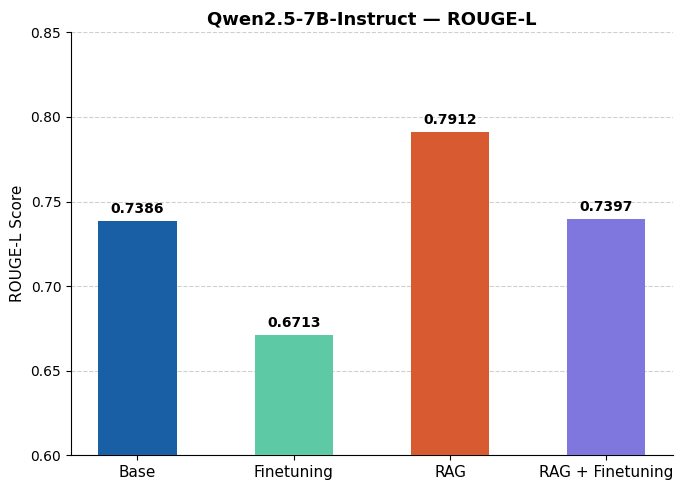

In [1]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Base', 'Finetuning', 'RAG', 'RAG + Finetuning']
values = [0.7386, 0.6713, 0.7912, 0.7397]
colors = ['#185FA5', '#5DCAA5', '#D85A30', '#7F77DD']

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(x, values, color=colors, width=0.5, zorder=3)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0.60, 0.85)
ax.set_ylabel('ROUGE-L Score', fontsize=11)
ax.set_title('Qwen2.5-7B-Instruct — ROUGE-L', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rouge_l.png', dpi=150)
plt.show()

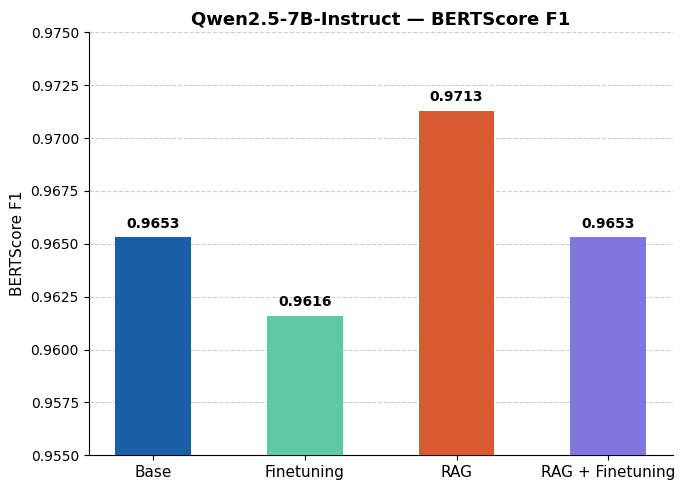

In [2]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Base', 'Finetuning', 'RAG', 'RAG + Finetuning']
values = [0.9653, 0.9616, 0.9713, 0.9653]
colors = ['#185FA5', '#5DCAA5', '#D85A30', '#7F77DD']

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(x, values, color=colors, width=0.5, zorder=3)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0.955, 0.975)
ax.set_ylabel('BERTScore F1', fontsize=11)
ax.set_title('Qwen2.5-7B-Instruct — BERTScore F1', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('bertscore_f1.png', dpi=150)
plt.show()

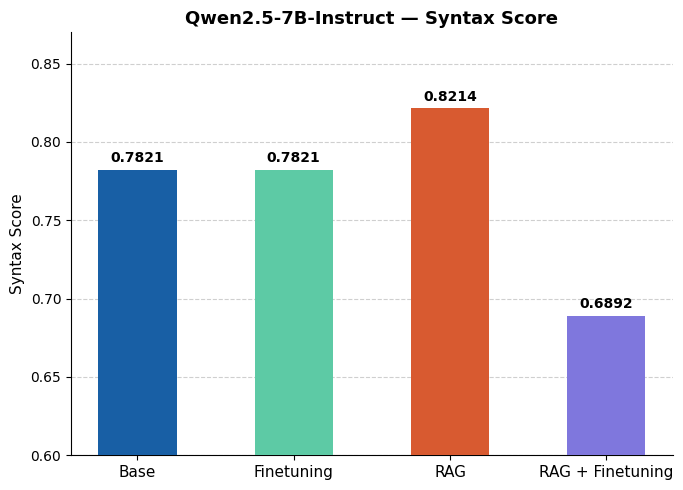

In [4]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Base', 'Finetuning', 'RAG', 'RAG + Finetuning']
values = [0.7821, 0.7821, 0.8214, 0.6892]
colors = ['#185FA5', '#5DCAA5', '#D85A30', '#7F77DD']

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(x, values, color=colors, width=0.5, zorder=3)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0.60, 0.87)
ax.set_ylabel('Syntax Score', fontsize=11)
ax.set_title('Qwen2.5-7B-Instruct — Syntax Score', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('syntax_score.png', dpi=150)
plt.show()

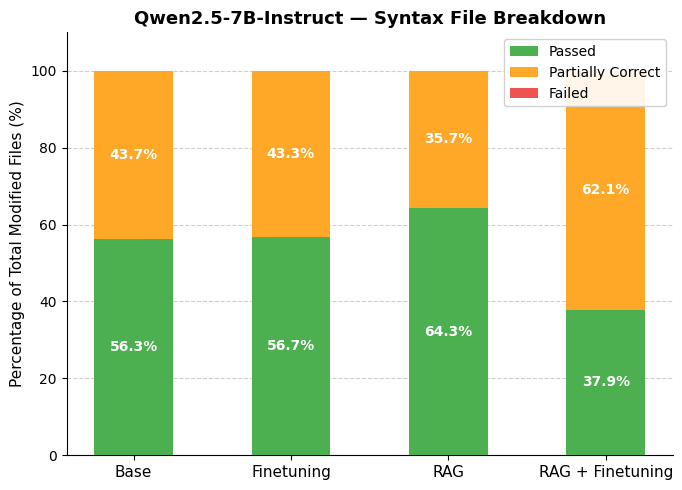

In [3]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Base', 'Finetuning', 'RAG', 'RAG + Finetuning']

total    = [142, 141, 140, 140]
passed   = [80,  80,  90,  53]
partial  = [62,  61,  50,  87]
failed   = [0,   0,   0,   0]

passed_pct  = [p / t * 100 for p, t in zip(passed,  total)]
partial_pct = [p / t * 100 for p, t in zip(partial, total)]
failed_pct  = [p / t * 100 for p, t in zip(failed,  total)]

x = np.arange(len(labels))
width = 0.5

fig, ax = plt.subplots(figsize=(7, 5))

bar1 = ax.bar(x, passed_pct,  width, label='Passed',           color='#4CAF50', zorder=3)
bar2 = ax.bar(x, partial_pct, width, label='Partially Correct', color='#FFA726',
              bottom=passed_pct, zorder=3)
bar3 = ax.bar(x, failed_pct,  width, label='Failed',           color='#EF5350',
              bottom=[p + q for p, q in zip(passed_pct, partial_pct)], zorder=3)

def label_segment(bars, bottoms, values):
    for bar, bottom, val in zip(bars, bottoms, values):
        if val > 2:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom + val / 2,
                    f'{val:.1f}%',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')

label_segment(bar1, [0] * len(labels),      passed_pct)
label_segment(bar2, passed_pct,              partial_pct)
label_segment(bar3, [p + q for p, q in zip(passed_pct, partial_pct)], failed_pct)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 110)
ax.set_ylabel('Percentage of Total Modified Files (%)', fontsize=11)
ax.set_title('Qwen2.5-7B-Instruct — Syntax File Breakdown', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.savefig('syntax_breakdown.png', dpi=150)
plt.show()